# Task 2 Customer Segmentation Using Unsupervised Learning

## Introduction and problem statement: 

Customer segmentation is used to group mall customers based on their income and spending behavior to better understand their purchasing patterns. In this project, K-Means clustering is applied to identify distinct customer segments and PCA is used for visualization. The goal is to help the mall design targeted marketing strategies for each group.

In [52]:
# Import required libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [53]:
# Loading dataset
df = pd.read_csv("Mall_Customers.csv")

In [54]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [55]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (200, 5)


In [56]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [57]:
# Check for missing values
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [58]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [59]:
# First five rows
df.head()

# Last five rows
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


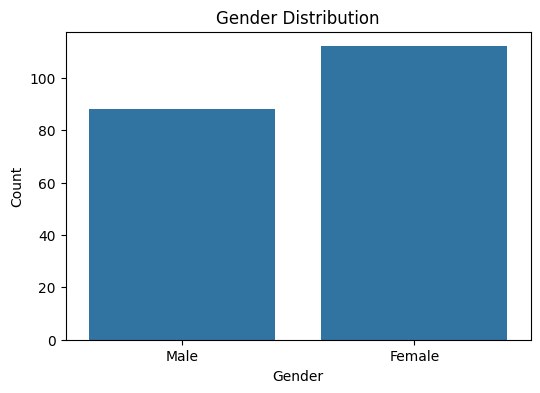

In [60]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

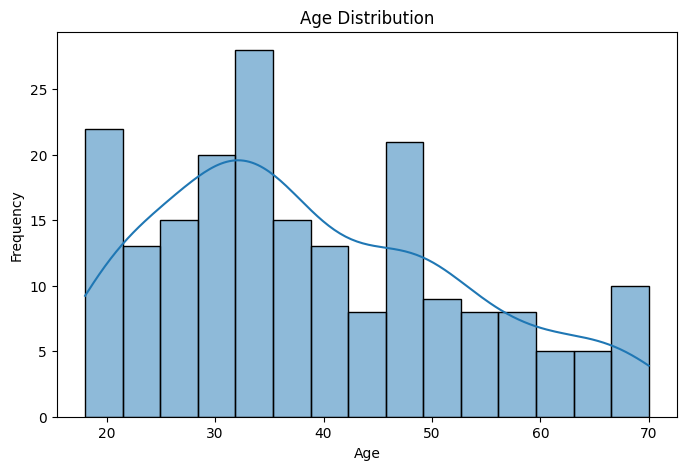

In [61]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=15, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

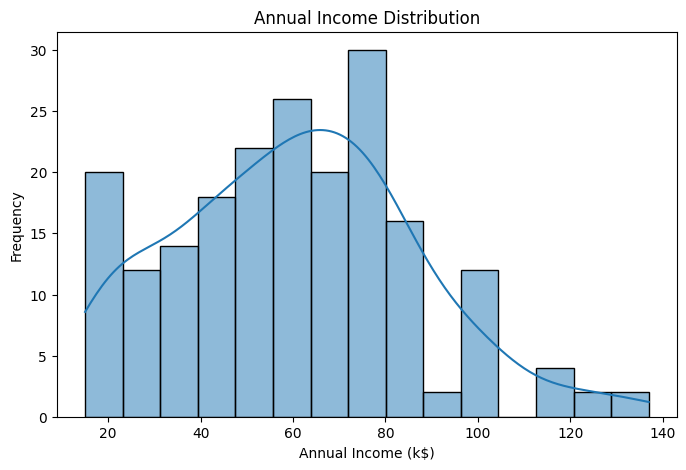

In [62]:
plt.figure(figsize=(8,5))
sns.histplot(df['Annual Income (k$)'], bins=15, kde=True)
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')
plt.show()

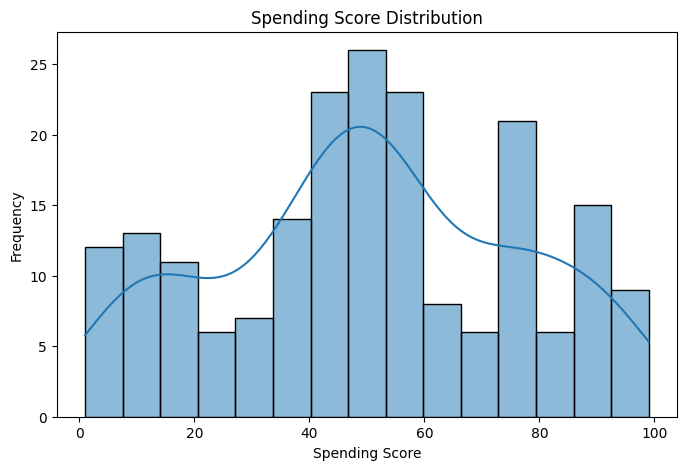

In [63]:
plt.figure(figsize=(8,5))
sns.histplot(df['Spending Score (1-100)'], bins=15, kde=True)
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Frequency')
plt.show()

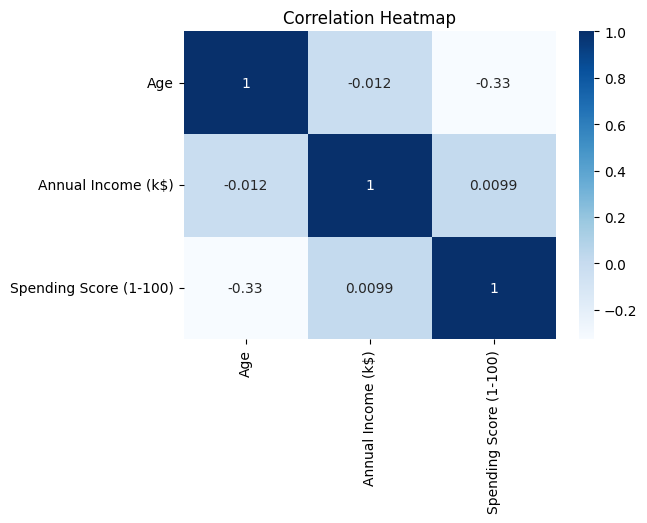

In [64]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df.drop(columns=['CustomerID']).select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Heatmap')
plt.show()

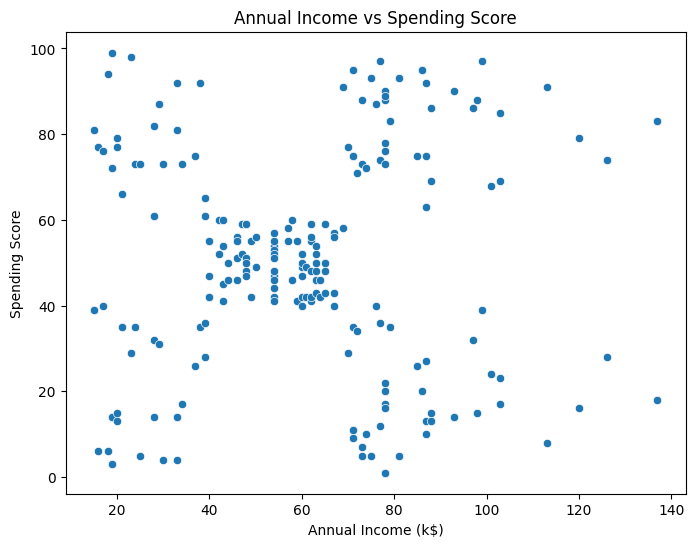

In [65]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.show()

In [66]:
# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Display first few rows
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [67]:
# Standardize the selected features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [68]:
# Find the optimal number of clusters using the Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

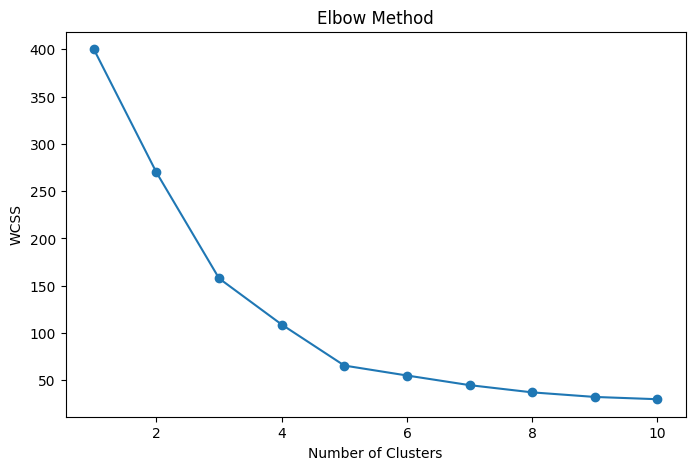

In [69]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [70]:
# Train the K-Means model
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

In [71]:
# Add cluster labels to the original dataset
df['Cluster'] = clusters

# Display first few rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [72]:
# Count customers in each cluster
print(df['Cluster'].value_counts())

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [73]:
# Apply PCA to reduce the data to 2 dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [74]:
# Create a DataFrame containing the PCA components and cluster labels
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

pca_df['Cluster'] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,-1.537109,-0.922207,4
1,-0.384168,-2.075149,2
2,-2.416002,0.010665,4
3,-0.466982,-1.938355,2
4,-1.455678,-0.895678,4


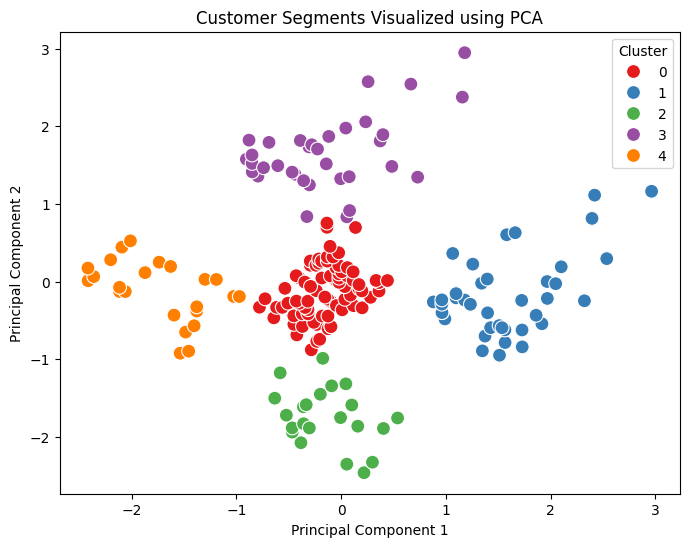

In [75]:
# Plot the clusters using PCA components
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    data=pca_df,
    s=100
)

plt.title('Customer Segments Visualized using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

In [76]:
# Display the average values for each cluster
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


## Conclusion

K-Means clustering successfully segmented mall customers into distinct groups based on their annual income and spending score. PCA visualization showed that the customer segments are clearly distinguishable. By understanding the characteristics of each segment, the mall can implement targeted marketing strategies such as loyalty programs, personalized promotions, VIP benefits, and discount campaigns. These strategies can improve customer satisfaction, increase sales, and support more effective marketing decisions.